# Feature Scaling & Normalization — a step-by-step, runnable notebook

A model that measures *distance* or learns by *gradient descent* reads your features in whatever **units** you happen to give it. If one feature is numbered in the thousands and another in the tenths, the big-numbered one silently dominates — not because it matters more, but because its units are bigger. **Feature scaling** puts every feature on a common ruler so the model judges them on merit, not magnitude.

This notebook shows that, one measurement at a time, on the **real Wine dataset** (178 wines, 13 chemical measurements, 3 cultivars — it ships with scikit-learn, no download). It is the executable companion to the chapter and to `feature_scaling.py`; every function used here lives in that module, imported so the notebook and the module can never drift apart.

By the end you will have **measured**, not just been told:

1. that one feature (`proline`) owns **~99.7%** of the raw Euclidean distance — and a fair ~1/13 after scaling;
2. the three scalers (**standard**, **min-max**, **robust**) built from scratch and **matched to scikit-learn**;
3. scaling lifting **KNN 0.72 → 0.96** and **SVM 0.67 → 1.00**, while a random forest **never moves**;
4. *why* — an unscaled nearest-neighbour query grabs the wrong neighbours, and gradient descent diverges;
5. why you **fit the scaler on the training split only**.

Everything runs on CPU in a couple of seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from feature_scaling import (
    load_wine_split, feature_ranges, distance_share,
    StandardScalerScratch, MinMaxScalerScratch, RobustScalerScratch,
    scaler_match_report, evaluate_models, gd_conditioning, logreg_iterations,
    leakage_probe, SKEWED_FEATURE, MATCH_TOL,
)

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__}')
split = load_wine_split()
print(f'Wine: {split.x_train.shape[0]} train + {split.x_test.shape[0]} test wines, '
      f'{len(split.feature_names)} features, {len(np.unique(split.y_train))} cultivars')

numpy 2.4.6 | scikit-learn 1.9.0
Wine: 124 train + 54 test wines, 13 features, 3 cultivars


## Step 1 — The problem: features on wildly different scales

Look at the **range** (max − min) of each Wine feature. `proline` (a concentration, in the hundreds to thousands) spans thousands of units; `nonflavanoid_phenols` spans about half a unit. That is a **~2,500×** gap — and a distance-based model measures closeness in exactly these raw units.

In [2]:
ranges = feature_ranges(split.x_train)
order = np.argsort(ranges)[::-1]
print(f'{"feature":<26}{"range (max-min)":>16}')
for i in order:
    print(f'{split.feature_names[i]:<26}{ranges[i]:>16.3f}')
print(f'\nlargest range / smallest range = {ranges.max() / ranges.min():,.0f}x')

feature                    range (max-min)
proline                           1237.000
magnesium                           92.000
alcalinity_of_ash                   19.400
color_intensity                     11.720
malic_acid                           5.060
alcohol                              3.800
flavanoids                           3.400
proanthocyanins                      3.160
total_phenols                        2.900
od280/od315_of_diluted_wines           2.650
ash                                  1.860
hue                                  1.230
nonflavanoid_phenols                 0.500

largest range / smallest range = 2,474x


## Step 2 — Quantify it: one feature owns the distance

Euclidean distance² is a **sum over features** of $(x_i - x'_i)^2$. Averaged over all pairs of wines, each feature's contribution is proportional to its **variance**. So we can compute exactly what fraction of 'how far apart two wines are' each feature owns — before and after standardizing.

In [3]:
share = distance_share(split.x_train, split.feature_names)
top = int(np.argmax(share.raw_share))
print(f'{"feature":<26}{"raw share":>12}{"scaled share":>14}')
idx = np.argsort(share.raw_share)[::-1]
for i in idx[:5]:
    print(f'{split.feature_names[i]:<26}{share.raw_share[i]*100:>11.2f}%{share.scaled_share[i]*100:>13.2f}%')
print(f'\n{split.feature_names[top]!r}: {share.raw_share[top]*100:.1f}% of the raw distance '
      f'-> {share.scaled_share[top]*100:.1f}% after standardizing (a fair 1/13 = {100/13:.1f}%).')
print('Unscaled, "nearest neighbour" essentially means "nearest in proline". That is the disease.')

feature                      raw share  scaled share
proline                         99.73%         7.69%
magnesium                        0.24%         7.69%
alcalinity_of_ash                0.01%         7.69%
color_intensity                  0.01%         7.69%
malic_acid                       0.00%         7.69%

'proline': 99.7% of the raw distance -> 7.7% after standardizing (a fair 1/13 = 7.7%).
Unscaled, "nearest neighbour" essentially means "nearest in proline". That is the disease.


## Step 3 — The three scalers, from scratch

Three ways to put a feature on a common ruler — each fit on the **training split only**:

* **standardize**: $z = (x-\mu)/\sigma$ → mean 0, std 1 (preserves shape; does not resist outliers);
* **min-max**: $(x-\min)/(\max-\min)$ → bounded to $[0,1]$ (an outlier fixes an endpoint);
* **robust**: $(x-\text{median})/\text{IQR}$ → median 0, IQR 1 (outlier-resistant).

Here are all three on the first few test values of `proline`.

In [4]:
j = split.feature_names.index('proline')
col_tr = split.x_train[:, j:j+1]
col_te = split.x_test[:, j:j+1]
std = StandardScalerScratch.fit(col_tr)
mm = MinMaxScalerScratch.fit(col_tr)
rb = RobustScalerScratch.fit(col_tr)
print(f'proline fit stats (train): mean={std.mean_[0]:.1f} std={std.std_[0]:.1f} '
      f'min={mm.min_[0]:.1f} range={mm.range_[0]:.1f} median={rb.median_[0]:.1f} IQR={rb.iqr_[0]:.1f}')
print(f'{"raw":>10}{"standard":>12}{"minmax":>10}{"robust":>10}')
for r, s, m, b in zip(col_te[:5,0], std.transform(col_te)[:5,0], mm.transform(col_te)[:5,0], rb.transform(col_te)[:5,0]):
    print(f'{r:>10.1f}{s:>12.3f}{m:>10.3f}{b:>10.3f}')

proline fit stats (train): mean=748.3 std=306.8 min=278.0 range=1237.0 median=675.0 IQR=487.5
       raw    standard    minmax    robust
    1185.0       1.423     0.733     1.046
     355.0      -1.282     0.062    -0.656
    1680.0       3.036     1.133     2.062
    1295.0       1.782     0.822     1.272
    1020.0       0.885     0.600     0.708


## Step 4 — Are they correct? Match against scikit-learn

Our from-scratch scalers should reproduce scikit-learn's `StandardScaler` / `MinMaxScaler` / `RobustScaler` to machine precision when fed the identical data. If they do, the transforms above are the genuine article — not a lookalike.

In [5]:
report = scaler_match_report(split)
for name, diff in report.items():
    print(f'{name:>9}: max|ours - sklearn| = {diff:.2e}  match: {bool(diff < MATCH_TOL)}')
assert all(d < MATCH_TOL for d in report.values()), 'scalers must match scikit-learn'
print('\n=> all three match to 1e-9. The from-scratch transforms are exact.')

 standard: max|ours - sklearn| = 2.18e-11  match: True
   minmax: max|ours - sklearn| = 2.12e-12  match: True
   robust: max|ours - sklearn| = 1.38e-11  match: True

=> all three match to 1e-9. The from-scratch transforms are exact.


## Step 5 — See how they treat outliers: a real skewed feature

`magnesium` is a real right-skewed Wine feature with high outliers. Watch what each scaler does — the *shape* is identical (scaling is an affine map), but **read the x-axis**: min-max lets the outlier pin the max at 1 and squashes the bulk into a narrow band near 0; robust centres the median at 0 with the bulk well-spread, leaving the outlier far out where it belongs.

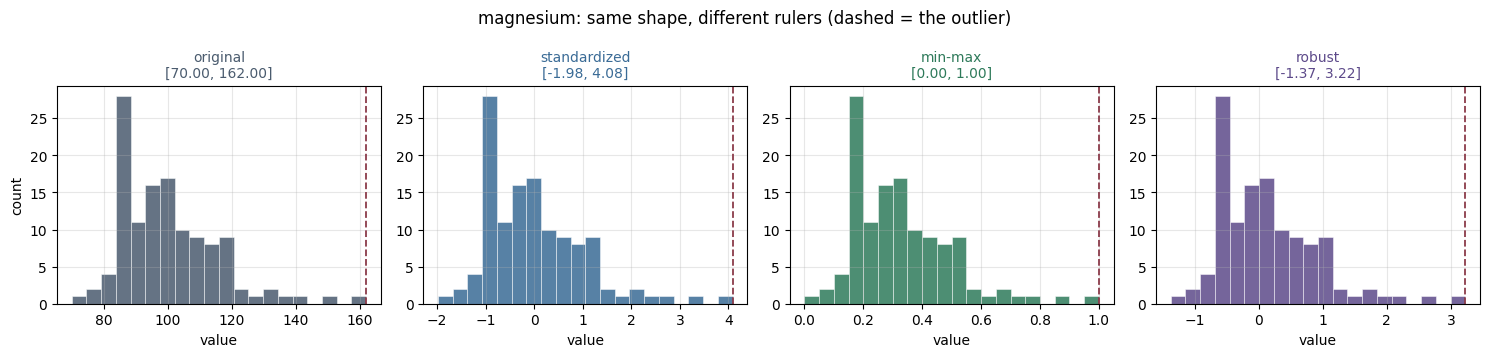

In [6]:
j = split.feature_names.index(SKEWED_FEATURE)
col = split.x_train[:, j:j+1]
views = [('original', col.ravel(), '#4A5B6E'),
         ('standardized', StandardScalerScratch.fit(col).transform(col).ravel(), '#3A6B96'),
         ('min-max', MinMaxScalerScratch.fit(col).transform(col).ravel(), '#2E7A5A'),
         ('robust', RobustScalerScratch.fit(col).transform(col).ravel(), '#5D4A8A')]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (title, vals, colour) in zip(axes, views):
    ax.hist(vals, bins=20, color=colour, alpha=0.85, edgecolor='white', lw=0.4)
    ax.axvline(vals.max(), color='#8B3B4A', ls='--', lw=1.3)
    ax.set_title(f'{title}\n[{vals.min():.2f}, {vals.max():.2f}]', color=colour, fontsize=10)
    ax.set_xlabel('value')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('count')
plt.suptitle(f'{SKEWED_FEATURE}: same shape, different rulers (dashed = the outlier)', fontsize=12)
plt.tight_layout()
plt.show()

## Step 6 — The money result: scaling changes real model accuracy

Train four models on the same split, **without** scaling and **with** each scaler (fit on train only). Three are scale-sensitive (KNN and the RBF-SVM use distance; logistic regression is gradient-trained); the **random forest** splits on thresholds and should be immune. Watch the distance-based models leap.

In [7]:
scores = evaluate_models(split)
print(f'{"model":<13}' + ''.join(f'{s:>10}' for s in scores.scaler_names))
for m in scores.model_names:
    row = ''.join(f'{a:>10.3f}' for a in scores.accuracy[m])
    tag = '   <- INVARIANT' if m == 'RandomForest' else ''
    print(f'{m:<13}{row}{tag}')
knn, svm = scores.accuracy['KNN'], scores.accuracy['SVM-RBF']
print(f'\nKNN:     {knn[0]:.3f} (none) -> {max(knn):.3f} (best scaler)  = +{(max(knn)-knn[0])*100:.0f} points')
print(f'SVM-RBF: {svm[0]:.3f} (none) -> {max(svm):.3f} (best scaler)  = +{(max(svm)-svm[0])*100:.0f} points')

model              none  standard    minmax    robust
KNN               0.722     0.944     0.963     0.926
SVM-RBF           0.667     0.981     1.000     0.981
LogReg            0.963     0.981     1.000     0.981
RandomForest      1.000     1.000     1.000     1.000   <- INVARIANT

KNN:     0.722 (none) -> 0.963 (best scaler)  = +24 points
SVM-RBF: 0.667 (none) -> 1.000 (best scaler)  = +33 points


## Step 7 — The same result, as a picture

One bar chart makes the story unmissable: the distance/gradient models jump when scaled; the random forest is a flat wall of equal bars.

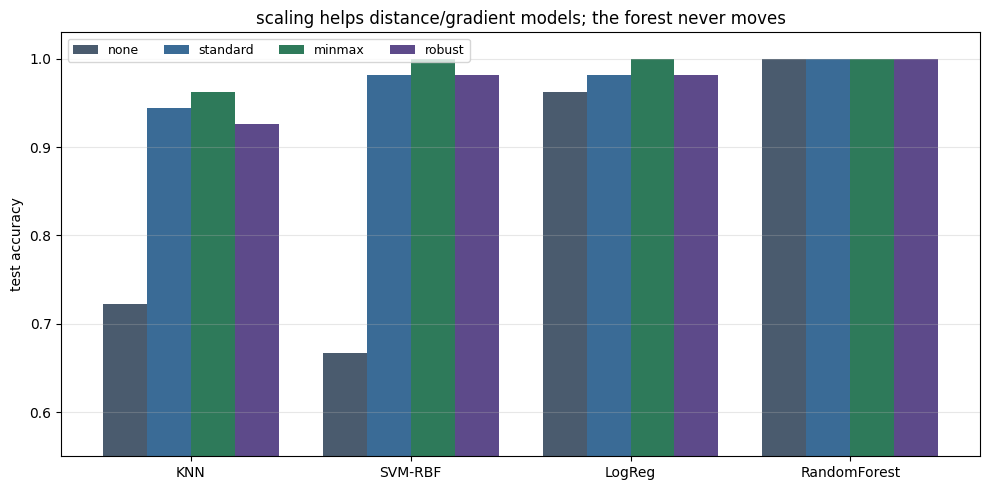

In [8]:
colours = {'none': '#4A5B6E', 'standard': '#3A6B96', 'minmax': '#2E7A5A', 'robust': '#5D4A8A'}
x = np.arange(len(scores.model_names))
w = 0.2
plt.figure(figsize=(10, 5))
for k, s in enumerate(scores.scaler_names):
    h = [scores.accuracy[m][k] for m in scores.model_names]
    plt.bar(x + (k-1.5)*w, h, w, color=colours[s], label=s)
plt.xticks(x, scores.model_names)
plt.ylim(0.55, 1.03)
plt.ylabel('test accuracy')
plt.title('scaling helps distance/gradient models; the forest never moves')
plt.legend(ncol=4, fontsize=9)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Step 8 — Why the forest is immune: monotone-invariant splits

A tree asks yes/no questions like `proline <= 755`. Any scaling is *monotone* — it preserves order — so the very same rows fall on each side of every threshold; only the number in the question changes. The tree structure, and therefore the predictions, are **identical**. We can check that directly: the forest's predictions are bit-for-bit the same under every scaler.

In [9]:
print(f'random-forest predictions identical across all scalers: {scores.rf_predictions_identical}')
print('scaling is monotone -> thresholds map 1:1 -> same splits -> same tree -> same predictions.')
print('If your whole pipeline is trees/GBMs, scaling is optional. For everything else, it is not.')

random-forest predictions identical across all scalers: True
scaling is monotone -> thresholds map 1:1 -> same splits -> same tree -> same predictions.
If your whole pipeline is trees/GBMs, scaling is optional. For everything else, it is not.


## Step 9 — Why gradient descent needs it: conditioning

Run the **same** from-scratch logistic-regression gradient descent (same learning rate) on two Wine features, raw vs standardized. The **condition number** of the feature covariance measures how *elongated* the loss surface's contours are. Raw, it is ~$10^5$: a razor-thin valley, where a step big enough to move along the valley overshoots across it and the loss **diverges**. Standardized, it is ~3, and the same step converges.

In [10]:
demo = gd_conditioning(split)
print(f'condition number of the loss surface: raw {demo.cond_raw:,.0f}   scaled {demo.cond_scaled:.1f}')
print(f'from-scratch GD (lr={demo.lr}) final loss: raw {demo.loss_raw[-1]:.3f}   scaled {demo.loss_scaled[-1]:.3f}')
print('same optimizer, same step size, same data -> only the feature scale changed the geometry.')

condition number of the loss surface: raw 131,513   scaled 3.0
from-scratch GD (lr=0.01) final loss: raw 11.021   scaled 0.567
same optimizer, same step size, same data -> only the feature scale changed the geometry.


## Step 10 — The loss curves, plotted

Raw features (red) send the loss oscillating high — the step overshoots the thin valley every iteration. Standardized features (green) descend smoothly. This is the optimization cost of skipping the scaler, made visible.

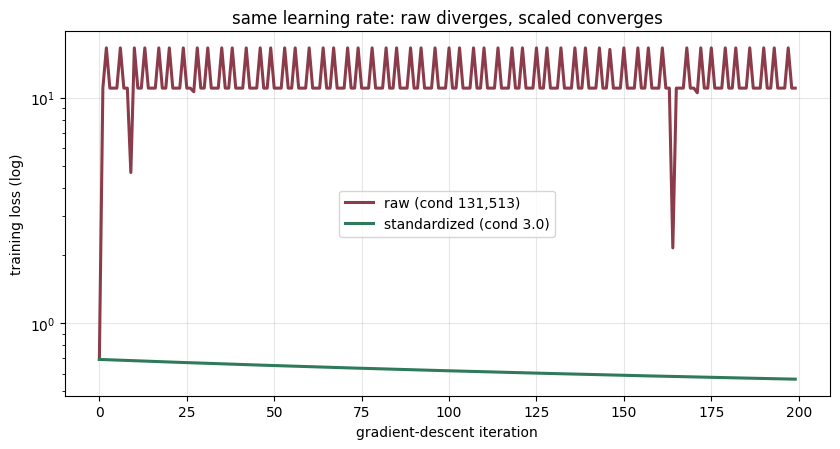

In [11]:
it = np.arange(len(demo.loss_raw))
plt.figure(figsize=(8.5, 4.6))
plt.plot(it, demo.loss_raw, color='#8B3B4A', lw=2.2, label=f'raw (cond {demo.cond_raw:,.0f})')
plt.plot(it, demo.loss_scaled, color='#2E7A5A', lw=2.2, label=f'standardized (cond {demo.cond_scaled:.1f})')
plt.yscale('log')
plt.xlabel('gradient-descent iteration')
plt.ylabel('training loss (log)')
plt.title('same learning rate: raw diverges, scaled converges')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 — Even scikit-learn's solver pays the price

This is not a from-scratch artefact. scikit-learn's own `LogisticRegression` (a good quasi-Newton solver) needs **thousands** of iterations to converge on unscaled Wine, and a **handful** once it is standardized. Scaling doesn't just help hand-rolled gradient descent — it conditions the problem for every gradient-based method.

In [12]:
n_raw, n_scaled = logreg_iterations(split)
print(f'LogisticRegression iterations to converge:  unscaled {n_raw:>6}   standardized {n_scaled:>4}')
print(f'-> standardizing cut the iteration count by ~{n_raw / max(n_scaled, 1):,.0f}x.')

LogisticRegression iterations to converge:  unscaled   6911   standardized   17
-> standardizing cut the iteration count by ~407x.


## Step 12 — Fit on TRAIN only (a data-leakage preview)

One rule ties scaling to honest evaluation: **fit the scaler on the training split only**, then apply it to test. If you fit on the whole dataset before splitting, the test set's own statistics leak into its transform — the model gets a peek at data it won't have in production. Here we *measure* the leak: how far the fitted statistics move, and how much a transformed test value changes. It is small for scaling — but the habit is non-negotiable, and the dramatic cases are the Data Leakage chapter.

In [13]:
probe = leakage_probe(split)
print(f'fitting on all data (vs train-only) shifts the mean by up to {probe.mean_shift.max():.3f}')
print(f'and the std by up to {probe.std_shift.max():.3f} per feature')
print(f'largest change in a transformed TEST value: {probe.max_test_transform_diff:.4f}')
print('\nSmall here, but always: split first, fit the scaler on train, then transform test.')

fitting on all data (vs train-only) shifts the mean by up to 1.437
and the std by up to 7.197 per feature
largest change in a transformed TEST value: 0.2111

Small here, but always: split first, fit the scaler on train, then transform test.


## Recap

On the real Wine dataset, one runnable notebook showed the whole of feature scaling:

| Step | What we measured | The takeaway |
|---|---|---|
| 1–2 | feature ranges; distance decomposition | one feature (`proline`) owns **~99.7%** of raw distance |
| 3–4 | the three scalers, from scratch | standard / min-max / robust, **matched to scikit-learn** |
| 5 | scalers on a skewed feature | min-max is outlier-sensitive; **robust resists outliers** |
| 6–7 | model accuracy without vs with | **KNN 0.72→0.96, SVM 0.67→1.00**; the forest never moves |
| 8 | random-forest invariance | monotone splits ⇒ **identical** predictions under any scaler |
| 9–11 | gradient-descent conditioning | raw cond ~$10^5$ diverges; scaled ~3 converges (thousands→tens of iters) |
| 12 | fit on train only | test statistics must not leak into the transform |

**Scaling changes the ruler, not the information.** Distance-based models (KNN, SVM-RBF, k-means, PCA) and gradient-based models (linear/logistic regression, neural nets) *need* it; tree ensembles don't. Fit on the training split, apply everywhere, and put every feature on an even footing.